In [8]:
import yfinance as yf
import pandas as pd 
import numpy as np 
import sys
!{sys.executable} -m pip install scikit-learn
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.3 MB 6.0 MB/s eta 0:00:07
   -- ------------------------------------- 2.1/37.3 MB 4.9 MB/s eta 0:00:08
   --- ------------------------------------ 2.9/37.3 MB 4.2 MB/s eta 0:00:09
   ---- ----------------------------------- 3.9/37.3 MB 4.6 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/37.3 MB 5.2 MB/s eta 0:00:07
   ---


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\junay\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [9]:
ticker = yf.Ticker("AAPL")
df = ticker.history(period="1y")
print(df.head())
print(df.shape)

                                 Open        High         Low       Close  \
Date                                                                        
2025-03-12 00:00:00-04:00  219.184697  220.787711  213.977397  216.038406   
2025-03-13 00:00:00-04:00  215.012876  215.899013  207.515554  208.770081   
2025-03-14 00:00:00-04:00  210.333268  213.021548  208.670517  212.563553   
2025-03-17 00:00:00-04:00  212.384327  214.286042  209.058824  213.071335   
2025-03-18 00:00:00-04:00  213.230666  214.216361  210.572254  211.767044   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-03-12 00:00:00-04:00  62547500        0.0           0.0  
2025-03-13 00:00:00-04:00  61368300        0.0           0.0  
2025-03-14 00:00:00-04:00  60107600        0.0           0.0  
2025-03-17 00:00:00-04:00  48073400        0.0           0.0  
2025-03-18 00:00:00-04:00  42432400        0.0           0.0  
(251, 7)


In [10]:
df['Tomorrow'] = df['Close'].shift(-1)
df['Targer'] = (df['Tomorrow'] > df['Close']).astype(int)

In [13]:
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['Price_vs_MA5'] = df['Close'] / df['MA5']
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily_Return'].rolling(window=5).std()
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df = df.dropna()
print(df[['Close', 'MA5', 'MA20', 'Target']].tail(10))


                                Close         MA5        MA20  Target
Date                                                                 
2026-02-25 00:00:00-05:00  274.230011  267.541998  267.472775       0
2026-02-26 00:00:00-05:00  272.950012  270.016003  268.310262       0
2026-02-27 00:00:00-05:00  264.179993  269.936005  268.617334       1
2026-03-02 00:00:00-05:00  264.720001  269.644006  268.891463       0
2026-03-03 00:00:00-05:00  263.750000  267.966003  268.591083       0
2026-03-04 00:00:00-05:00  262.519989  265.623999  268.255678       0
2026-03-05 00:00:00-05:00  260.290009  263.091998  267.458603       0
2026-03-06 00:00:00-05:00  257.459991  261.747998  266.548999       1
2026-03-09 00:00:00-04:00  259.880005  260.779999  265.650000       1
2026-03-10 00:00:00-04:00  260.829987  260.195996  264.960500       0


In [14]:
features = ['MA5', 'MA20', 'Price_vs_MA5', 'Daily_Return', 'Volatility']
X = df[features]
y = df['Target']


In [15]:
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [16]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Accuracy: 58.14%


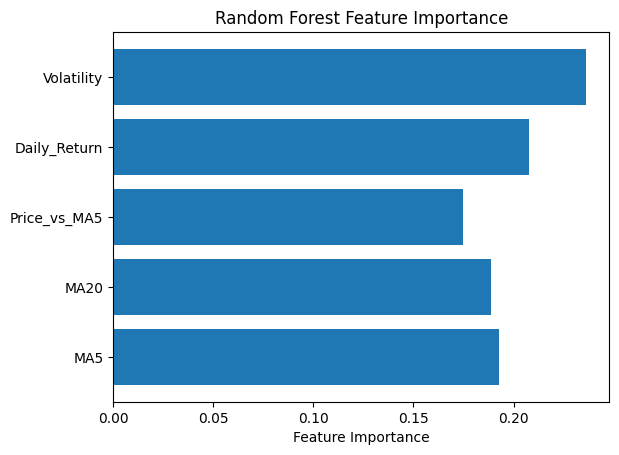

In [19]:
y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2%}')
import matplotlib.pyplot as plt
importances = model.feature_importances_
plt.barh(features, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()